In [33]:
import sys
from os.path import dirname

sys.path.append("../src/")

ERROR! Session/line number was not unique in database. History logging moved to new session 3091


In [34]:
import copy
from collections import Counter, defaultdict
from typing import List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pysam
import scipy as spy
import seaborn as sns
import sklearn as sk
import torch
from ExoModel.exo_model import ExoModel

# from NucDPosITv2.em_nuc_model import CoordinateProbs, EMTorch
from nuc_template_constants import ExoNucTemplate
from scipy.stats import gaussian_kde
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

In [57]:
BAM_PATH = "../data/reads/M_musculus/SRR2229625/SRR2229625.sorted_bam"
BAM_FILE = pysam.AlignmentFile(BAM_PATH)

<Axes: >

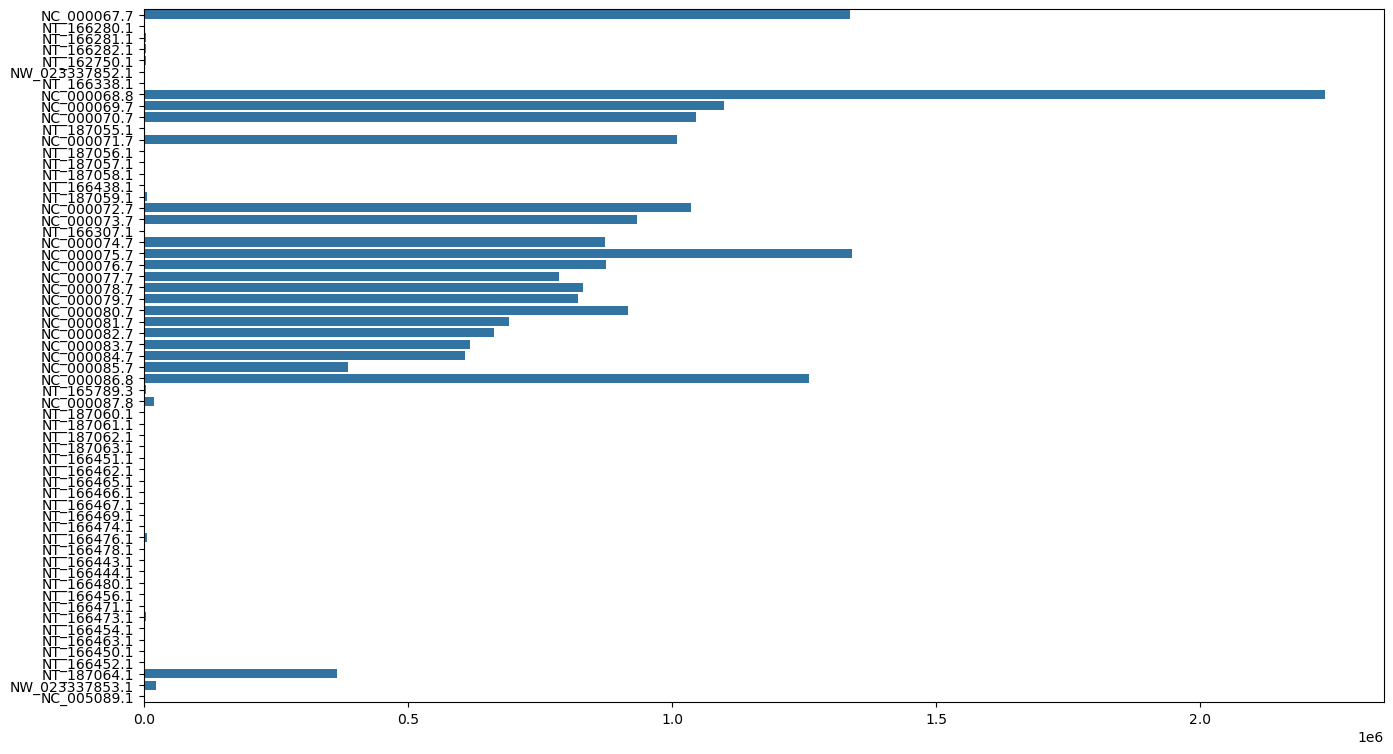

In [58]:
bam_file = pysam.AlignmentFile(BAM_PATH, "rb")

# Словарь для хранения результатов
counts = {}

# Проходим по всем ссылкам (хромосомам) в заголовке BAM
for ref in bam_file.references:
    mapped_reads = bam_file.count(ref)
    counts[ref] = mapped_reads

# Закрываем файл
bam_file.close()

plt.figure(figsize=(16, 9))
sns.barplot(counts, orient='h')

In [23]:
# def calculate_template_length_distribution(bam_file, log_iter=1000000):
#     # Открываем BAM файл
#     bam = pysam.AlignmentFile(bam_file, "rb")

#     # Словарь для хранения распределения длин
#     length_dist = Counter()
#     total_pairs = 0

#     # Проходим по всем выравниваниям
#     for read in bam:
#         # Проверяем, что read является парным и правильно выровненным
#         if read.is_paired and read.is_proper_pair and read.template_length > 0:
#             # Берем абсолютное значение длины шаблона
#             tl = read.template_length
#             length_dist[tl] += 1
#             total_pairs += 1
#             if total_pairs % log_iter == 0:
#                 print(f"processed {total_pairs} reads")

#     bam.close()
#     return length_dist, total_pairs

In [5]:
# tlens, all_counts = calculate_template_length_distribution(BAM_PATH)

In [6]:
# hist = [tlens[i] / all_counts for i in range(0, 199)]

In [7]:
# errors = np.loadtxt("../data/autocor_errors/SRR1802184_errors.csv")
# plt.plot(errors)

In [37]:
class BamFileIterator:
    def __init__(
        self,
        pysam_path,
        chromosome,
        window_size=4000,
        start=0,
        stop=None,
        step=3500,
        device="cpu",
    ):
        self.al_file = pysam.AlignmentFile(pysam_path)
        self.chromosome = chromosome
        self.window_size = window_size
        self.step = step
        self.__initial_start = start
        self.__stop = (
            stop
            if stop
            else dict(zip(self.al_file.references, self.al_file.lengths))[chromosome]
        )
        self.device = device

    @property
    def initial_start(self):
        return self.__initial_start

    @property
    def stop(self):
        return self.__stop

        self.chromo_len = dict(zip(self.al_file.references, self.al_file.lengths))[
            chromosome
        ]

    def __del__(self):
        self.al_file.close()

    def __iter__(self):
        self.cur_start = self.initial_start
        self.cur_stop = self.cur_start + self.window_size
        self.stop_iter = False
        return self

    def __next__(self):
        if self.stop_iter == True:
            raise StopIteration

        if self.cur_stop >= self.stop:
            self.stop_iter = True

        records = list(
            self.al_file.fetch(self.chromosome, self.cur_start, self.cur_stop)
        )
        paired_records = self._collect_paired_reads(records)
        items = {
            "start": torch.tensor(
                list(map(lambda x: x[0].reference_start, paired_records))
            ).view(-1, 1),
            "end": torch.tensor(
                list(map(lambda x: x[1].reference_end, paired_records))
            ).view(-1, 1),
            "id": list(map(lambda x: x[0].qname, paired_records)),
        }
        self.cur_start += self.step
        self.cur_stop = self.cur_start + self.window_size
        return items

    def _collect_paired_reads(self, records):
        read_pairs = defaultdict(dict)
        valid_pairs = []

        for read in records:
            name = read.query_name
            if read.is_read1:
                read_pairs[name]["R1"] = read
            elif read.is_read2:
                read_pairs[name]["R2"] = read

        # Отбираем только полные пары
        for name, pair in read_pairs.items():
            if (
                "R1" in pair
                and "R2" in pair
                and pair["R2"].reference_end - pair["R1"].reference_start <= 195
            ):
                valid_pairs.append((pair["R1"], pair["R2"]))
        return valid_pairs

In [38]:
import copy

import torch


class EMModel:
    def __init__(
        self,
        errors,
        dyad_dist,
        max_iter=500,
        reg_coef=0,
        tol=0.0001,
        device="cpu",
        alpha=0.5,
    ):
        self.device = device
        self.errors = errors.to(device)
        self.dyad_dist = dyad_dist
        self.max_iter = max_iter
        self.reg_coef = reg_coef
        self.tol = tol
        self.alpha = alpha

    @property
    def nreads(self):
        return len(self.starts)

    @property
    def ndyads(self):
        return len(self.dyads)

    def __validate_cords(self, cords):
        return cords.to(self.device)

    def __validate_dyads(self, dyads=None):
        if dyads is None:
            dyads = (
                torch.arange(
                    self.starts.min(),
                    self.stops.max() + 1,
                    self.dyad_dist,
                    device=self.device,
                )
                .int()
                .reshape(-1, 1)
            )
        return dyads

    def __validate_weights(self, weights=None):
        if weights is None:
            weights = torch.rand(self.ndyads, dtype=float, device=self.device).reshape(
                -1, 1
            )
            weights /= weights.sum()
        return weights

    def __create_probs_matrix(self, dyads):
        # dyads имеет размерность [n, 1]
        n_dyads = dyads.shape[0]
        n_reads = self.nreads

        # Используем broadcasting без создания промежуточных тензоров ones
        left_diff = dyads - self.starts.view(1, -1)  # [n, nreads]
        right_diff = self.stops.view(1, -1) - dyads  # [n, nreads]

        L_index = self.__insert_probs_to_matrix(left_diff, self.errors)
        R_index = self.__insert_probs_to_matrix(right_diff, self.errors)

        return (L_index * R_index).T

    def __create_grid_probs(self):
        potential_dyads = torch.arange(
            self.starts.min(), self.stops.max() + 1, device=self.device
        ).reshape(
            -1, 1
        )  # [grid_size, 1]

        probs = torch.log(self.__create_probs_matrix(potential_dyads) + 1e-50)
        return probs

    def __insert_probs_to_matrix(self, idx_matrix, errors):
        # idx_matrix: [n, nreads]

        # Округляем до целых индексов
        idx = idx_matrix.round().long()

        # Создаем маску валидных индексов
        valid_mask = (idx >= 0) & (idx < len(errors))

        # Быстрое заполнение через advanced indexing
        result = torch.zeros_like(idx_matrix, dtype=float) + 1e-50

        # Получаем индексы для валидных элементов
        valid_indices = idx[valid_mask]

        # Заполняем значения
        result[valid_mask] = errors[valid_indices]

        return result

    def e_step(self):
        self.probs_matrix = self.__create_probs_matrix(self.dyads)
        self.Hij = (self.probs_matrix * self.weights.T) / (
            self.probs_matrix @ self.weights
        )
        if self.Hij.isnan().any():
            raise ValueError("Has None")

    def m_step(self):
        self.dyads = (
            self.starts.min()
            + torch.argmax(self.grid_probs.T @ self.Hij, dim=0, keepdim=True).T
        )
        self.weights = self.Hij.sum(0, keepdim=True).T
        self.weights = self.weights / self.weights.sum() - self.reg_coef
        self.weights[self.weights < 0] = 0
        self.weights /= self.weights.sum()
        if (self.weights == 0).all() or self.weights.isnan().all():
            raise ValueError("all weights = 0. It seems reg_coef is too high")

    def delete_components(self):
        keep_alive_mask = (self.weights > 0).bool().reshape(-1, 1)
        self.weights = self.weights[keep_alive_mask].reshape(-1, 1)
        self.weights /= self.weights.sum()
        self.dyads = self.dyads[keep_alive_mask].reshape(-1, 1)
        self.probs_matrix = self.__create_probs_matrix(self.dyads)

    def to(self, device):
        """Move model to specified device"""
        self.device = device
        self.starts = self.starts.to(device)
        self.stops = self.stops.to(device)
        self.errors = self.errors.to(device)
        self.dyads = self.dyads.to(device)
        self.weights = self.weights.to(device)
        if self.probs_matrix is not None:
            self.probs_matrix = self.probs_matrix.to(device)
        if self.Hij is not None:
            self.Hij = self.Hij.to(device)

    def get_params(self):
        params = {
            "L": self.starts,
            "R": self.stops,
            "errors": self.errors,
            "dyad_dist": self.dyad_dist,
            "max_iter": self.max_iter,
            "reg_coef": self.reg_coef,
            "tol": self.tol,
            "dyads": self.dyads,
            "weights": self.weights,
            "device": self.device,
        }
        return params

    def logLH(self):
        lh = torch.log((self.probs_matrix * self.weights.T).sum(axis=0)).sum()
        return lh

    def fit(self, starts, stops, dyads=None, weights=None):
        self.starts = self.__validate_cords(starts)
        self.stops = self.__validate_cords(stops)
        self.dyads = self.__validate_dyads(dyads)
        self.probs_matrix = self.__create_probs_matrix(self.dyads)
        self.grid_probs = self.__create_grid_probs()
        self.weights = self.__validate_weights(weights)
        self.e_step()

        prev_lh = -100000
        prev_sliding_mean = -100000
        lh_loss = []
        sliding_mean_list = []

        for i in range(self.max_iter):
            self.e_step()
            self.m_step()
            self.delete_components()

            cur_lh = self.logLH()
            lh_loss.append(cur_lh.item())

            # Правильное экспоненциальное скользящее среднее
            if i == 0:
                sliding_mean = cur_lh  # Первое значение равно самому значению
            else:
                sliding_mean = (
                    self.alpha * cur_lh + (1 - self.alpha) * prev_sliding_mean
                )

            sliding_mean_list.append(sliding_mean.item())

            # Обновляем предыдущие значения
            prev_lh = cur_lh
            delta_sliding_mean = sliding_mean - prev_sliding_mean
            prev_sliding_mean = sliding_mean

            if delta_sliding_mean < self.tol:
                self.e_step()
                return lh_loss, sliding_mean_list, True
        self.e_step()
        return lh_loss, sliding_mean_list, False


class StochasticEMMOdel(EMModel):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def m_step(self):
        # Оптимизируем выборку
        stochastic_res = self.__sample_multinomial_vectorized_torch()

        # Оптимизируем вычисление dyads
        # Используем einsum или matmul для более эффективного умножения
        weighted_sum = torch.matmul(self.grid_probs.T, stochastic_res)
        max_indices = torch.argmax(weighted_sum, dim=0, keepdim=True).T
        self.dyads = self.starts.min() + max_indices

        # Оптимизируем вычисление weights
        self.weights = stochastic_res.sum(0, keepdim=True).T

        # Нормализация с регуляризацией за один проход
        weights_sum = self.weights.sum()
        if weights_sum != 1:
            self.weights = self.weights / weights_sum - self.reg_coef
        else:
            self.weights = self.weights - self.reg_coef

        # Быстрая замена отрицательных значений
        self.weights = torch.where(
            self.weights < 0, torch.tensor(0.0, device=self.device), self.weights
        )
        self.weights = self.weights / self.weights.sum()

    def __sample_multinomial_vectorized_torch(self):
        # Быстрая проверка на NaN
        if torch.isnan(self.Hij).any():
            raise ValueError("Hij matrix contains nan")

        # Оптимизированная мультиномиальная выборка
        # Используем torch.multinomial с оптимизациями
        samples = torch.multinomial(self.Hij, num_samples=1).squeeze(-1)

        # Более эффективное создание one-hot encoding
        # Используем scatter_ вместо one_hot для скорости
        n_classes = self.Hij.shape[-1]
        stochastic_res = torch.zeros(
            (samples.shape[0], n_classes), device=self.device, dtype=torch.double
        )
        stochastic_res.scatter_(1, samples.unsqueeze(-1), 1.0)

        return stochastic_res

In [39]:
def make_df(model):
    if model.device != "cpu":
        model.to("cpu")
    df = pd.DataFrame({"start": model.starts.flatten(), "stop": model.stops.flatten()})
    df["dyads"] = model.dyads[model.Hij.argmax(1)]
    df["template|dyad"] = model.Hij.max(1)[0]
    return df


def make_occupancy(starts, stops):
    min_value = starts.min()
    max_value = stops.max()
    x = np.arange(min_value, max_value + 1)
    occ = np.zeros_like(x)
    for start, stop in zip(starts, stops):
        occ[start - min_value : stop - min_value + 1] += 1
    return x, occ


def make_template_occupancy(dyads, template):
    min_value = dyads.min()
    max_value = dyads.max()
    x = np.arange(min_value - len(template), max_value + len(template), dtype=float)
    occ = np.zeros_like(x)
    for dyad in dyads:
        start_pos = dyad - len(template) // 2 - min_value + len(template)
        occ[start_pos : start_pos + len(template)] += template
    return (
        x[len(template) // 2 : -len(template) // 2],
        occ[len(template) // 2 : -len(template) // 2],
    )

In [40]:
chrom_lengths = dict(zip(BAM_FILE.references, BAM_FILE.lengths))
chrom_lengths

{'NC_000067.7': 195154279,
 'NT_166280.1': 169725,
 'NT_166281.1': 241735,
 'NT_166282.1': 153618,
 'NT_162750.1': 206961,
 'NW_023337852.1': 8412,
 'NT_166338.1': 40056,
 'NC_000068.8': 181755017,
 'NC_000069.7': 159745316,
 'NC_000070.7': 156860686,
 'NT_187055.1': 1976,
 'NC_000071.7': 151758149,
 'NT_187056.1': 199368,
 'NT_187057.1': 205776,
 'NT_187058.1': 184189,
 'NT_166438.1': 195993,
 'NT_187059.1': 953012,
 'NC_000072.7': 149588044,
 'NC_000073.7': 144995196,
 'NT_166307.1': 175968,
 'NC_000074.7': 130127694,
 'NC_000075.7': 124359700,
 'NC_000076.7': 130530862,
 'NC_000077.7': 121973369,
 'NC_000078.7': 120092757,
 'NC_000079.7': 120883175,
 'NC_000080.7': 125139656,
 'NC_000081.7': 104073951,
 'NC_000082.7': 98008968,
 'NC_000083.7': 95294699,
 'NC_000084.7': 90720763,
 'NC_000085.7': 61420004,
 'NC_000086.8': 169476592,
 'NT_165789.3': 559103,
 'NC_000087.8': 91455967,
 'NT_187060.1': 182347,
 'NT_187061.1': 259875,
 'NT_187062.1': 155838,
 'NT_187063.1': 158099,
 'NT_166

In [41]:
templates1 = next(
    iter(BamFileIterator(BAM_PATH, "NC_000069.7", start=159745316 // 2, window_size=30000))
)
templates2 = next(
    iter(BamFileIterator(BAM_PATH, "NC_000069.7", start=159745316 // 2, window_size=30000))
)
templates3 = next(
    iter(BamFileIterator(BAM_PATH, "NC_000069.7", start=159745316 // 2, window_size=30000))
)

In [42]:
L1 = templates1["start"]
R1 = templates1["end"]

# L2 = templates2["start"]
# R2 = templates2["end"]

# L3 = templates3["start"]
# R3 = templates3["end"]

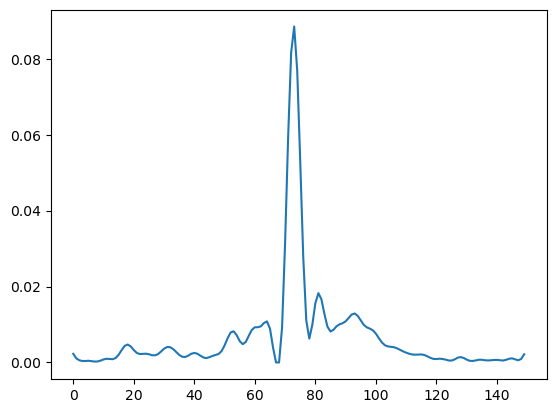

In [43]:
errors = torch.from_numpy(np.loadtxt("../data/reads/M_musculus/SRR2229626/SRR2229626_errors/SRR2229626_errors.csv"))
# z = torch.zeros(100)
# errors = torch.concat([errors, z])
plt.plot(errors)

In [44]:
L1

tensor([[79873007],
        [79873725],
        [79874904],
        [79875344],
        [79875493],
        [79875956],
        [79876589],
        [79876855],
        [79877417],
        [79877775],
        [79877939],
        [79879199],
        [79879449],
        [79879571],
        [79880189],
        [79881833],
        [79882232],
        [79882730],
        [79884856],
        [79885075],
        [79885200],
        [79885431],
        [79885480],
        [79886226],
        [79886288],
        [79888128],
        [79888371],
        [79888437],
        [79890341],
        [79890363],
        [79890394],
        [79890416],
        [79890498],
        [79891940],
        [79892323],
        [79892641],
        [79892898],
        [79893094],
        [79893107],
        [79893281],
        [79893858],
        [79894266],
        [79894618],
        [79894768],
        [79894983],
        [79895204],
        [79896062],
        [79896224],
        [79896728],
        [79897140],


In [45]:
EMModel(errors, 5, device="cpu", reg_coef=2 / len(L1))

In [46]:
import cProfile


def test_time():
    model = StochasticEMMOdel(
        errors, 5, device="cpu", reg_coef=2 / len(L1), max_iter=10
    )
    res = model.fit(L1, R1)
    return res


# m = test_time()
#

# cProfile.run('test_time()')

In [47]:
# model = StochasticEMMOdel(errors, 10, device="cuda:0", tol=0.01, max_iter=200, alpha=0.1)
# rmsd_loss = []

# for reg in tqdm(range(0, 30), total=30):

#     model.reg_coef = reg / len(L1)
#     res = model.fit(L1, R1)
#     torch.cuda.empty_cache()
#     df = make_df(model)
#     x, oc = make_occupancy(df.start.to_numpy(), df.stop.to_numpy())
#     bar_counter = Counter(df.dyads.value_counts().to_dict())
#     x_bars = [bar_counter[cord] for cord in x]
#     conv = np.convolve(x_bars, ExoNucTemplate().nuc_template, mode="same")
#     rmsd = model.ndyads * np.log(len(L1)) - 2 * model.logLH()
#     rmsd_loss.append(rmsd.item())
    
    
# plt.plot(rmsd_loss)

In [49]:
# scope = (R3.max() - L3.min())
model = StochasticEMMOdel(errors, 10, device="cpu", tol=0.01, max_iter=200, alpha=0.1, reg_coef=0)
res = model.fit(L1, R1)

<Axes: >

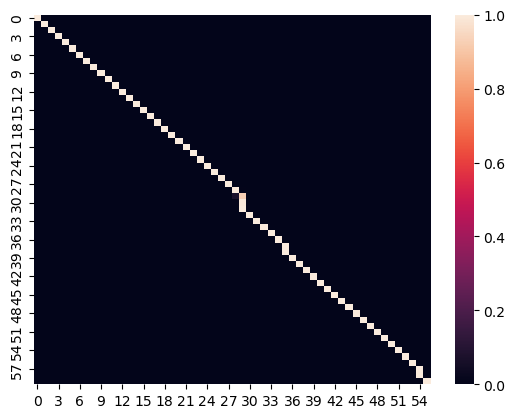

In [50]:
sns.heatmap(model.Hij.cpu())

In [51]:
model.e_step()

In [52]:
model.dyads.shape

torch.Size([56, 1])

In [53]:
model.Hij.shape

torch.Size([60, 56])

In [54]:
model.weights.shape

torch.Size([56, 1])

In [55]:
df = make_df(model)

0.030909169204524852


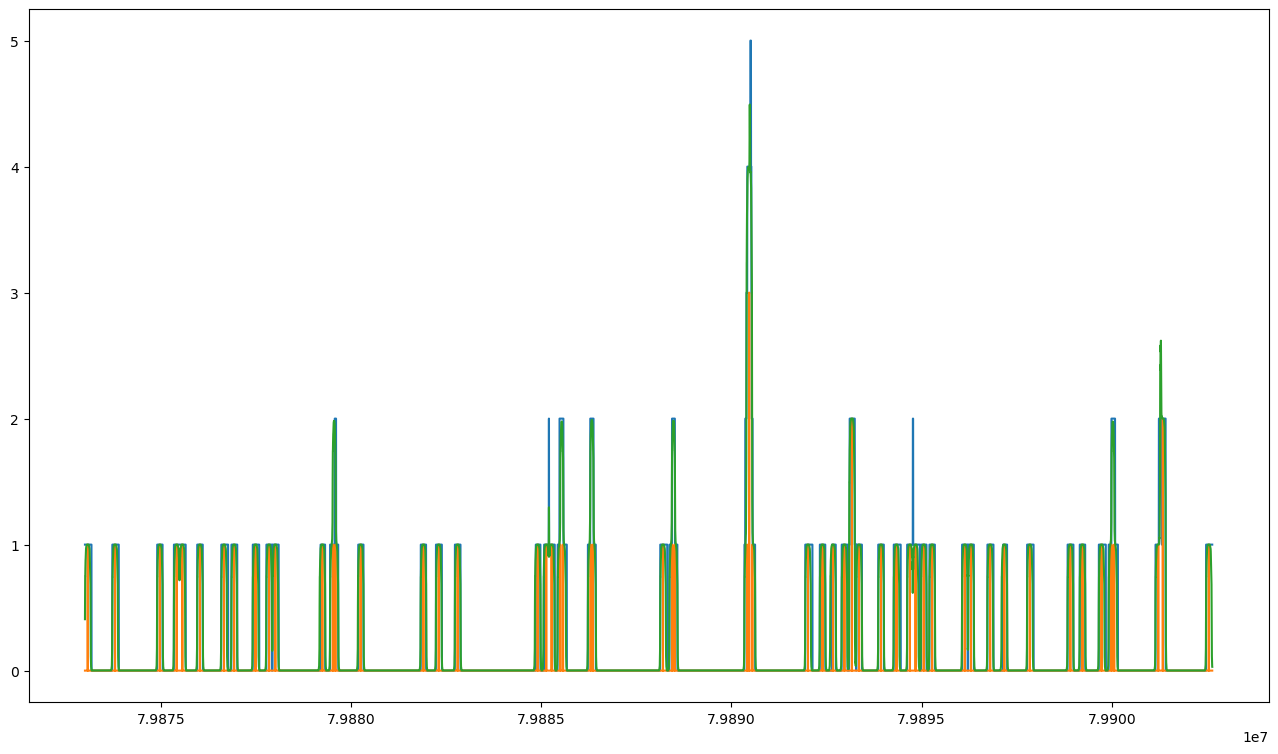

In [56]:
plt.figure(figsize=(16, 9))
x, oc = make_occupancy(df.start.to_numpy(), df.stop.to_numpy())

bar_counter = Counter(df.dyads.value_counts().to_dict())
x_bars = [bar_counter[cord] for cord in x]

plt.plot(x, oc)
plt.plot(x, x_bars)

conv = np.convolve(x_bars, ExoNucTemplate().nuc_template, mode="same")
plt.plot(x, conv)

rmsd = ((oc - conv) ** 2).sum() / len(x)
print(rmsd)

In [249]:
df = make_df(model)

In [149]:
df.groupby("dyads").count()

,start,stop,template|dyad
dyads,,,
6715,1,1,1
6753,1,1,1
6759,1,1,1
6790,7,7,7
6825,5,5,5
...,...,...,...
9507,3,3,3
9545,5,5,5
9586,5,5,5


In [ ]:
m1 = train_model(StochasticEMMOdel, L1, R1, errors, params, 30, 3)
m2 = train_model(StochasticEMMOdel, L2, R2, errors, params, 30, 3)
m3 = train_model(StochasticEMMOdel, L3, R3, errors, params, 30, 3)

In [ ]:
m1.to("cpu")
m2.to("cpu")
m3.to("cpu")

In [ ]:
# rmsd1 = grid_reg_coef(model1, np.linspace(0.0001, 1, 10))

# m2 = grid_search(model1, np.linspace(0.0001, 1, 10))

# m3 = grid_search(model1, np.linspace(0.0001, 1, 10))

In [ ]:
m3.Hij.max(1)[0].shape

In [ ]:
df1, df2, df3 = make_df(m1), make_df(m2), make_df(m3)
df1["label"] = 1
df2["label"] = 2
df3["label"] = 3

df = pd.concat([df1, df2, df3])

In [ ]:
df1

In [ ]:
x1, occ1 = make_occupancy(L1.numpy().flatten(), R1.numpy().flatten())
x2, occ2 = make_occupancy(L2.numpy().flatten(), R2.numpy().flatten())
x3, occ3 = make_occupancy(L3.numpy().flatten(), R3.numpy().flatten())

template_x1, templates_occ1 = make_template_occupancy(
    df1.dyads.to_numpy(), ExoNucTemplate().nuc_template
)
template_x2, templates_occ2 = make_template_occupancy(
    df2.dyads.to_numpy(), ExoNucTemplate().nuc_template
)
template_x3, templates_occ3 = make_template_occupancy(
    df3.dyads.to_numpy(), ExoNucTemplate().nuc_template
)

c1 = Counter(df1.dyads.values)
bars1 = [c1[i] for i in x1]

c2 = Counter(df2.dyads.values)
bars2 = [c2[i] for i in x2]

c3 = Counter(df3.dyads.values)
bars3 = [c3[i] for i in x3]

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(16, 9), sharex=True, sharey=False)


axs[0].plot(template_x1, templates_occ1)
axs[0].plot(x1, occ1)
axs[0].plot(x1, bars1)
axs[0].grid()

axs[1].plot(template_x2, templates_occ2)
axs[1].plot(x2, occ2)
axs[1].plot(x2, bars2)
axs[1].grid()

axs[2].plot(template_x3, templates_occ3)
axs[2].plot(x3, occ3)
axs[2].plot(x3, bars3)
axs[2].grid()

# fig.savefig("../data/figs/fit_exo_figs/tmp/convergence.png")

In [ ]:
m2.Hij.argmax(0).shape

In [ ]:
m2.dyads.shape

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9), sharex=True, sharey=True)


ax.plot(template_x1, templates_occ1)
ax.plot(x1, occ1)
ax.plot(x1, bars1)
ax.grid()

plt.xlim(20000, 22500)

In [ ]:
chromosomes = ["NC_001136.10"]

In [ ]:
for chromosome in chromosomes:
    bam_iterator = BamFileIterator(
        args.input, chromosome, window_size=args.window_size, step=args.step
    )

    for idx, batch in enumerate(bam_iterator):
        starts, ends = batch["start"], batch["end"]
        model = StochasticEMMOdel(
            starts,
            ends,
            errors,
            args.dyad_dist,
            reg_coef=0,
            max_iter=args.max_iter,
            device=args.device,
        )
        best_model = optimize_reg_coef(
            model, args.train_iter, args.max_successful_trains
        )
        best_model.to("cpu")

In [ ]:
model = StochasticEMMOdel(
    starts, ends, errors, 1, reg_coef=0, max_iter=600, device="cpu"
)

In [ ]:
device = "cuda"

In [ ]:
bam_iterator = BamFileIterator(
    BAM_PATH, "NC_001136.10", window_size=3000, start=157 * 300, device=device
)


for idx, batch in enumerate(bam_iterator):
    if idx == 154:
        starts = batch["start"]
        ends = batch["end"]
        params = {"dyad_dist": 1, "device": device}

        best_model = optimize_reg_coef(
            StochasticEMMOdel,
            starts,
            ends,
            errors,
            params,
            50,
            2,
        )

        df = make_df(best_model)
        break

In [ ]:
best_model.dyads.shape

In [ ]:
best_model.Hij.shape

In [ ]:
(ends - starts).argmax()

In [ ]:
len(errors)

In [ ]:
model = StochasticEMMOdel(starts, ends, errors, 1, reg_coef=0.0001)

In [ ]:
model.run()

In [ ]:
sns.heatmap(model.Hij)

In [ ]:
model.weights.shape

In [ ]:
starts.min()

In [ ]:
starts.max()

In [ ]:
d = torch.arange(starts.min(), starts.max() + 1, 1)

In [ ]:
l = d - starts[1197].float()
m_l = ((l >= 0) & (l < len(errors))).bool()
l[~m_l] = 0
l[m_l] = errors[l[m_l].int()].float()

r = ends[1197].float() - d
m_r = ((r >= 0) & (r < len(errors))).bool()
r[~m_r] = 0
r[m_r] = errors[r[m_r].int()].float()

In [ ]:
plt.plot(l)
plt.plot(r)

p = l * r
p /= p.sum()
plt.plot(p)

In [ ]:
starts[1197]

In [ ]:
bam_iterator = BamFileIterator(
    BAM_PATH, "NC_001136.10", window_size=3000, device="cuda:0"
)


for batch in bam_iterator:
    starts = batch["start"]
    ends = batch["end"]
    break

In [ ]:
starts.device

In [ ]:
torch.cuda.empty_cache()

In [ ]:
batch["start"].clone().to("cuda:0")

In [ ]:
best_model.dyads.isnan().any()

In [ ]:
sns.heatmap(best_model.Hij)

In [ ]:
best_model.probs_matrix.shape

In [ ]:
best_model.dyads.shape

In [ ]:
best_model.Hij.shape

In [ ]:
best_model.dyad_dist

In [ ]:
best_model.e_step()

In [ ]:
best_model.Hij.shape

In [ ]:
best_model.starts.to("cuda:0")

In [ ]:
best_model.starts.shape

In [ ]:
best_model.stops.shape

In [ ]:
plt.plot(*make_occupancy(starts.numpy().flatten(), stops.numpy().flatten()))